### Myrzakassymov Azizkhan
#### Machine Learning 
#### Practice 1

Dataset: Coffee Shop Sales
Transaction records for Maven Roasters, a fictitious coffee shop operating out of three NYC locations. Dataset includes the transaction date, timestamp and location, along with product-level details.

Recommended Analysis

1 - How have Maven Roasters sales trended over time?

2 - Which days of the week tend to be busiest, and why do you think that's the case?

3 - Which products are sold most and least often? Which drive the most revenue for the business?

#### Data Preview
transaction_id : Unique sequential ID representing an individual transaction

transaction_date : Date of the transaction (MM/DD/YY)

transaction_time : Timestamp of the transaction (HH:MM:SS)

transaction_qty : Quantity of items sold

store_id : Unique ID of the coffee shop where the transaction took place

store_location : Location of the coffee shop where the transaction took place

product_id : Unique ID of the product sold

unit_price : Retail price of the product sold

product_category : Description of the product category

product_type : Description of the product type

product_detail : Description of the product detail


### Exploratory Data-Analysis

### Problem definition
We are getting out of coffee beans and it isn't so important, should we buy it or not?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Dataset and demonstration

df = pd.read_excel("Coffee Shop Sales.xlsx")
df.fillna(0) # filling NaN values with 0
display(df.head()) # displaying the dataset

print(df.nunique().reset_index()) # showing all unique values in dataset
print(df.dtypes) # all datatypes

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


               index       0
0     transaction_id  149116
1   transaction_date     181
2   transaction_time   25762
3    transaction_qty       6
4           store_id       3
5     store_location       3
6         product_id      80
7         unit_price      41
8   product_category       9
9       product_type      29
10    product_detail      80
transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object


We can see that we have 3 relevant numerical columns: transaction_qty, unit_price, transaction time, but for analysis we will use transaction_qty and unit_price

Let's start with aggregated pivot table

In [3]:
# 1.
# Pivot table

pivot = pd.pivot_table(
    df, index ='store_location', columns='product_category',
      values='unit_price', aggfunc=['mean', 'median', 'sem', 'count'] # sem - standart error of mean 
)

display(pivot)


mean                                    \
product_category    Bakery    Branded    Coffee Coffee beans   
store_location                                                 
Astoria           3.545720  19.559140  3.024235    20.356972   
Hell's Kitchen    3.569378  16.319328  3.015869    21.507083   
Lower Manhattan   3.540106  16.727794  3.031622    20.981073   

                                                                           \
product_category Drinking Chocolate Flavours Loose Tea Packaged Chocolate   
store_location                                                              
Astoria                    4.144826      0.8  9.284884           9.906455   
Hell's Kitchen             4.159713      0.8  9.198660           8.623198   
Lower Manhattan            4.141850      0.8  9.339239           8.995333   

                           median  ...       sem  count                 \
product_category       Tea Bakery  ...       Tea Bakery Branded Coffee   
store_location                     ...                                   
Astoria           2.822429    3.5  ...  0.003126   7289     279  20025   
Hell's Kitchen    2.814699    3.5  ...  0.003159   7617     119  20187   
Lower Manhattan   2.813578    3.5  ...  0.003282   7890     349  18204   

                                                                     \
product_category Coffee beans Drinking Chocolate Flavours Loose Tea   
store_location                                                        
Astoria                   502               4300     1490       344   
Hell's Kitchen            720               3763     2370       485   
Lower Manhattan           531               3405     2930       381   

                                            
product_category Packaged Chocolate    Tea  
store_location                              
Astoria                         110  16260  
Hell's Kitchen                  197  15277  
Lower Manhattan                 180  13912  

[3 rows x 36 columns]

### Univariate analysis
Showing histogram, box plots, box charts
I will use numerical columns, aggregated by store location and product category

In [ ]:
used_columns = [
    'store_location',
    'product_category',
    'transaction_qty',
    'unit_price',
    'product_type',
]



C:\Users\azikc\AppData\Local\Temp\ipykernel_21424\1495369693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\azikc\AppData\Local\Temp\ipykernel_21424\1495369693.py:5: UserWarning: 
The palette list has fewer values (2) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


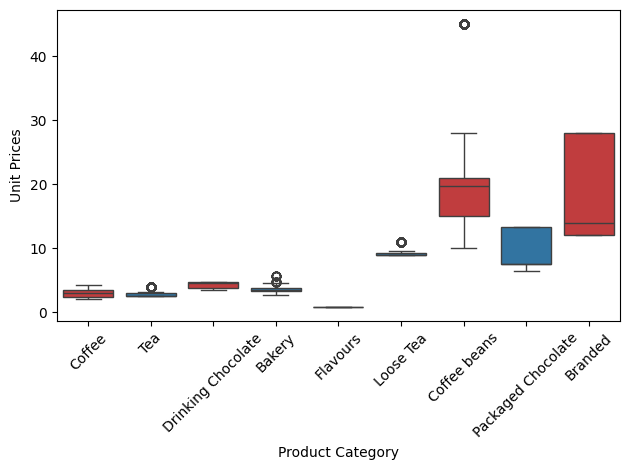

In [9]:
data = df[used_columns]

fig, ax = plt.subplots()

sns.boxplot(
    data=data,
    x='product_category',
    y='unit_price',
    palette=['tab:red', 'tab:blue'],
    ax=ax,
)

ax.set_ylabel('Unit Prices')
ax.set_xlabel('Product Category')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Very interseting, that most of the product categories prices are distributed quite uniformly.
But branded coffee and coffee beans are very various, though in coffee beans there's one outlier which costs 45 dollars or something

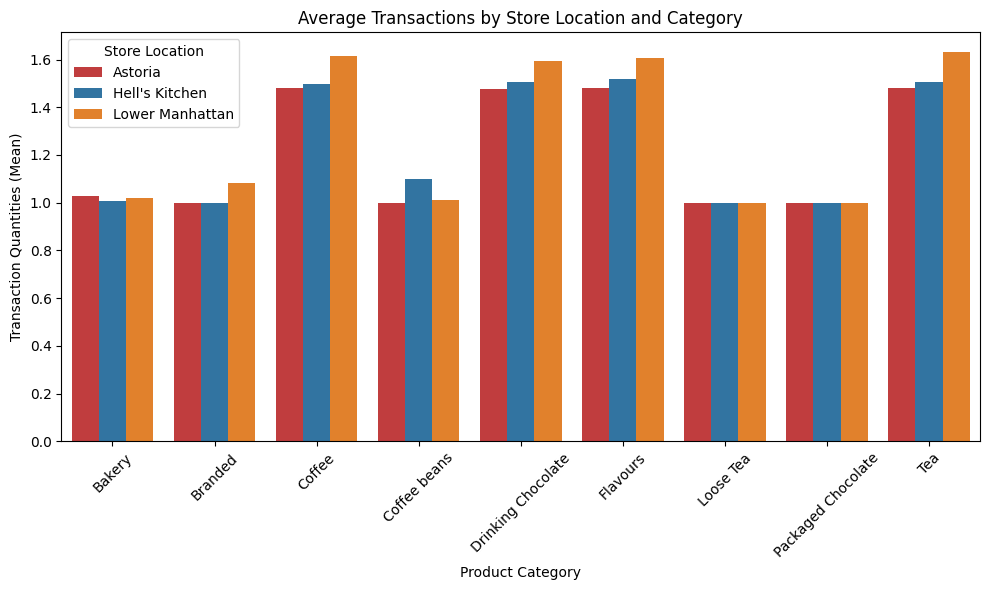

In [6]:
data = ( # data preparation
    df[used_columns]
    .groupby(['store_location', 'product_category'], as_index=False)[
        'transaction_qty'
    ]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=data,
    x='product_category',
    y='transaction_qty',
    hue='store_location',
    palette=['tab:red', 'tab:blue', 'tab:orange'],
    ax=ax,
)

ax.set_ylabel('Transaction Quantities (Mean)')
ax.set_xlabel('Product Category')
ax.set_title('Average Transactions by Store Location and Category')
plt.xticks(rotation=45)
plt.legend(title='Store Location')

plt.tight_layout()
plt.show()

We can see that in Lower Manhattan things is being bought more than one often than in other locations.